In [2]:
from functools import partial
from typing import Callable, Dict, Tuple

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from phd.jax_core.models import MLP
from phd.jax_core.optimizers import EqxOptimizer, optax_idbd
from phd.jax_core.tasks.geoff import NonlinearGEOFFTask
from phd.jax_core.utils import tree_replace

## Global Params

In [3]:
N_INPUTS = 10
N_OUTPUTS = 1

## Helper Functions

In [4]:
def create_network(
    n_layers: int, # 1 = linear
    hidden_dim: int,
    seed: int = 0,
):
    return MLP(
        input_dim = N_INPUTS,
        output_dim = N_OUTPUTS,
        n_layers = n_layers,
        hidden_dim = hidden_dim,
        weight_init_method = 'lecun_uniform',
        activation = 'leaky_relu',
        key = jax.random.PRNGKey(seed),
    )
    
def make_optimizer(
    network: MLP,
    step_size: float,
    meta_step_size: float,
) -> EqxOptimizer:
    return EqxOptimizer(
        optimizer = optax_idbd(
            init_lr = step_size,
            meta_lr = meta_step_size,
            autostep = True,
        ),
        model = network,
        name = 'Autostep',
    )
    
def create_task(seed: int = 0) -> NonlinearGEOFFTask:
    return NonlinearGEOFFTask(
        n_features = 5,
        flip_rate = 0.0004, # Flip every 500 steps
        n_layers = 1,
        seed = seed,
    )
    
class LearnerState(eqx.Module):
    network: MLP
    optimizer: EqxOptimizer

In [5]:
@partial(jax.jit, static_argnames=('train_steps', 'update_fn', 'n_seeds'))
def run_experiment(
    learner_state: LearnerState,
    train_steps: int,
    update_fn: Callable[[LearnerState, jax.Array, jax.Array], Tuple[LearnerState, Dict]],
    n_seeds: int,
):
    """Trains `learner_state` for `train_steps` steps with `update_fn`, vmapped over
    `n_seeds` seeds. Each seed gets its own task (and its own distractor noise) but the
    same starting learner. Returns metrics of shape (n_seeds, train_steps, ...)."""

    def train_step(carry, _):
        learner_state, task, key = carry
        key, noise_key = jax.random.split(key)

        # One sample: 5 informative features from the task, padded with distractor noise
        # up to the network's input dim (the learner has to learn to ignore the noise).
        task, (x, y) = task.generate_batch()
        x, y = x[0], y[0]
        n_distractors = learner_state.network.input_dim - x.shape[0]
        x = jnp.concatenate([x, jax.random.normal(noise_key, (n_distractors,))])

        # Online prediction error on this sample, then learn from it.
        pred, _ = learner_state.network(x)
        loss = jnp.mean((y - pred) ** 2)
        learner_state, metrics = update_fn(learner_state, x, y)

        return (learner_state, task, key), {'loss': loss, **metrics}

    def run_one(seed):
        carry = (learner_state, create_task(seed), jax.random.PRNGKey(seed))
        _, metrics = jax.lax.scan(train_step, carry, length=train_steps)
        return metrics

    return jax.vmap(run_one)(jnp.arange(n_seeds))

In [6]:

# Same as your idbd_update, but average step sizes over ALL hidden units:
# layers[0].weight is (hidden_dim, input_dim) -> split on the input axis.
def idbd_update(learner_state, x, y):
    network, optimizer = learner_state.network, learner_state.optimizer

    loss_grads = eqx.filter_grad(lambda net: jnp.mean((net(x)[0] - y) ** 2))(network)
    pred_grads = eqx.filter_grad(lambda net: net(x)[0].sum())(network)

    updates, optimizer = optimizer.with_update((loss_grads, pred_grads), network)
    network = eqx.apply_updates(network, updates)
    new_state = tree_replace(learner_state, network=network, optimizer=optimizer)

    step_sizes = jnp.exp(optimizer.state.beta.layers[0].weight)  # (hidden_dim, input_dim)
    return new_state, {
        'informative_step_size_mean': step_sizes[:, :5].mean(),
        'distractor_step_size_mean':  step_sizes[:, 5:].mean(),
    }

## Depth Tests

In [46]:
# Create networks with 10 inputs (5 informative, 5 distractors), 20 hidden units per layer, and 1 output layer.
# 
# Create networks with 0-6 hidden layers.
# Create a linear target network that determines the output (use NonlinearGEOFFTask)

# For each try training both versions of Autostep (inputs and predictions)

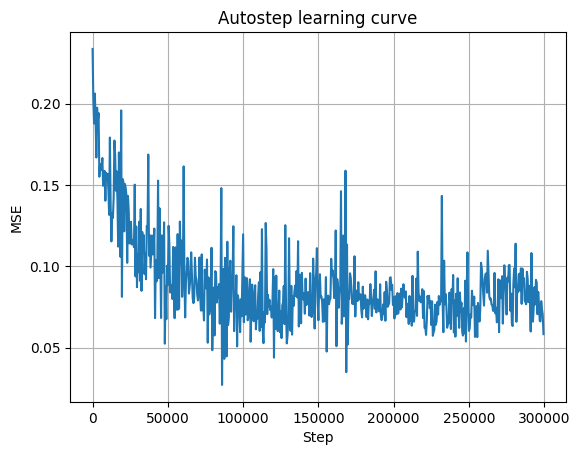

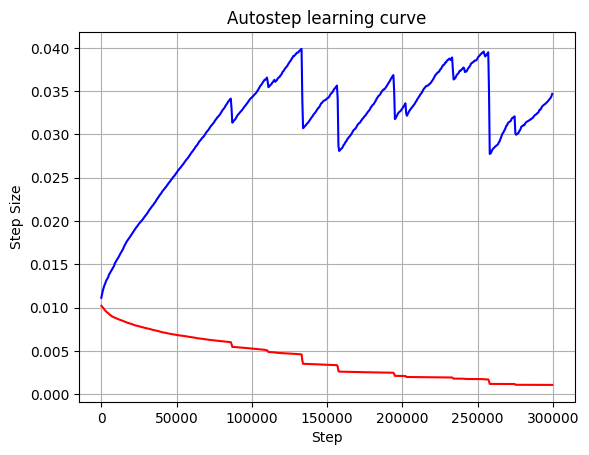

In [ ]:

### Quick smoke test: linear network, 5 seeds ###
bin_size = 500

network = create_network(n_layers=1, hidden_dim=20)
optimizer = make_optimizer(network, step_size=0.01, meta_step_size=0.01)
learner_state = LearnerState(network, optimizer)

metrics = run_experiment(learner_state, 300_000, idbd_update, n_seeds=5)

loss = np.asarray(metrics['loss']).mean(0)        # average over seeds
loss = loss.reshape(-1, bin_size).mean(1)              # smooth into 500-step bins
plt.plot(np.arange(len(loss)) * bin_size, loss)
plt.xlabel('Step'); plt.ylabel('MSE'); plt.title('Autostep learning curve'); plt.grid(True)
plt.show()

informative_step_sizes = np.asarray(metrics['informative_step_size_mean']).mean(0)        # average over seeds
informative_step_sizes = informative_step_sizes.reshape(-1, bin_size).mean(1)
distractor_step_sizes = np.asarray(metrics['distractor_step_size_mean']).mean(0)        # average over seeds
distractor_step_sizes = distractor_step_sizes.reshape(-1, bin_size).mean(1)

plt.plot(np.arange(len(informative_step_sizes)) * bin_size, informative_step_sizes, color='blue')
plt.plot(np.arange(len(distractor_step_sizes)) * bin_size, distractor_step_sizes, color='red')
plt.xlabel('Step'); plt.ylabel('Step Size'); plt.title('Autostep learning curve'); plt.grid(True)
plt.show()

Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will prob

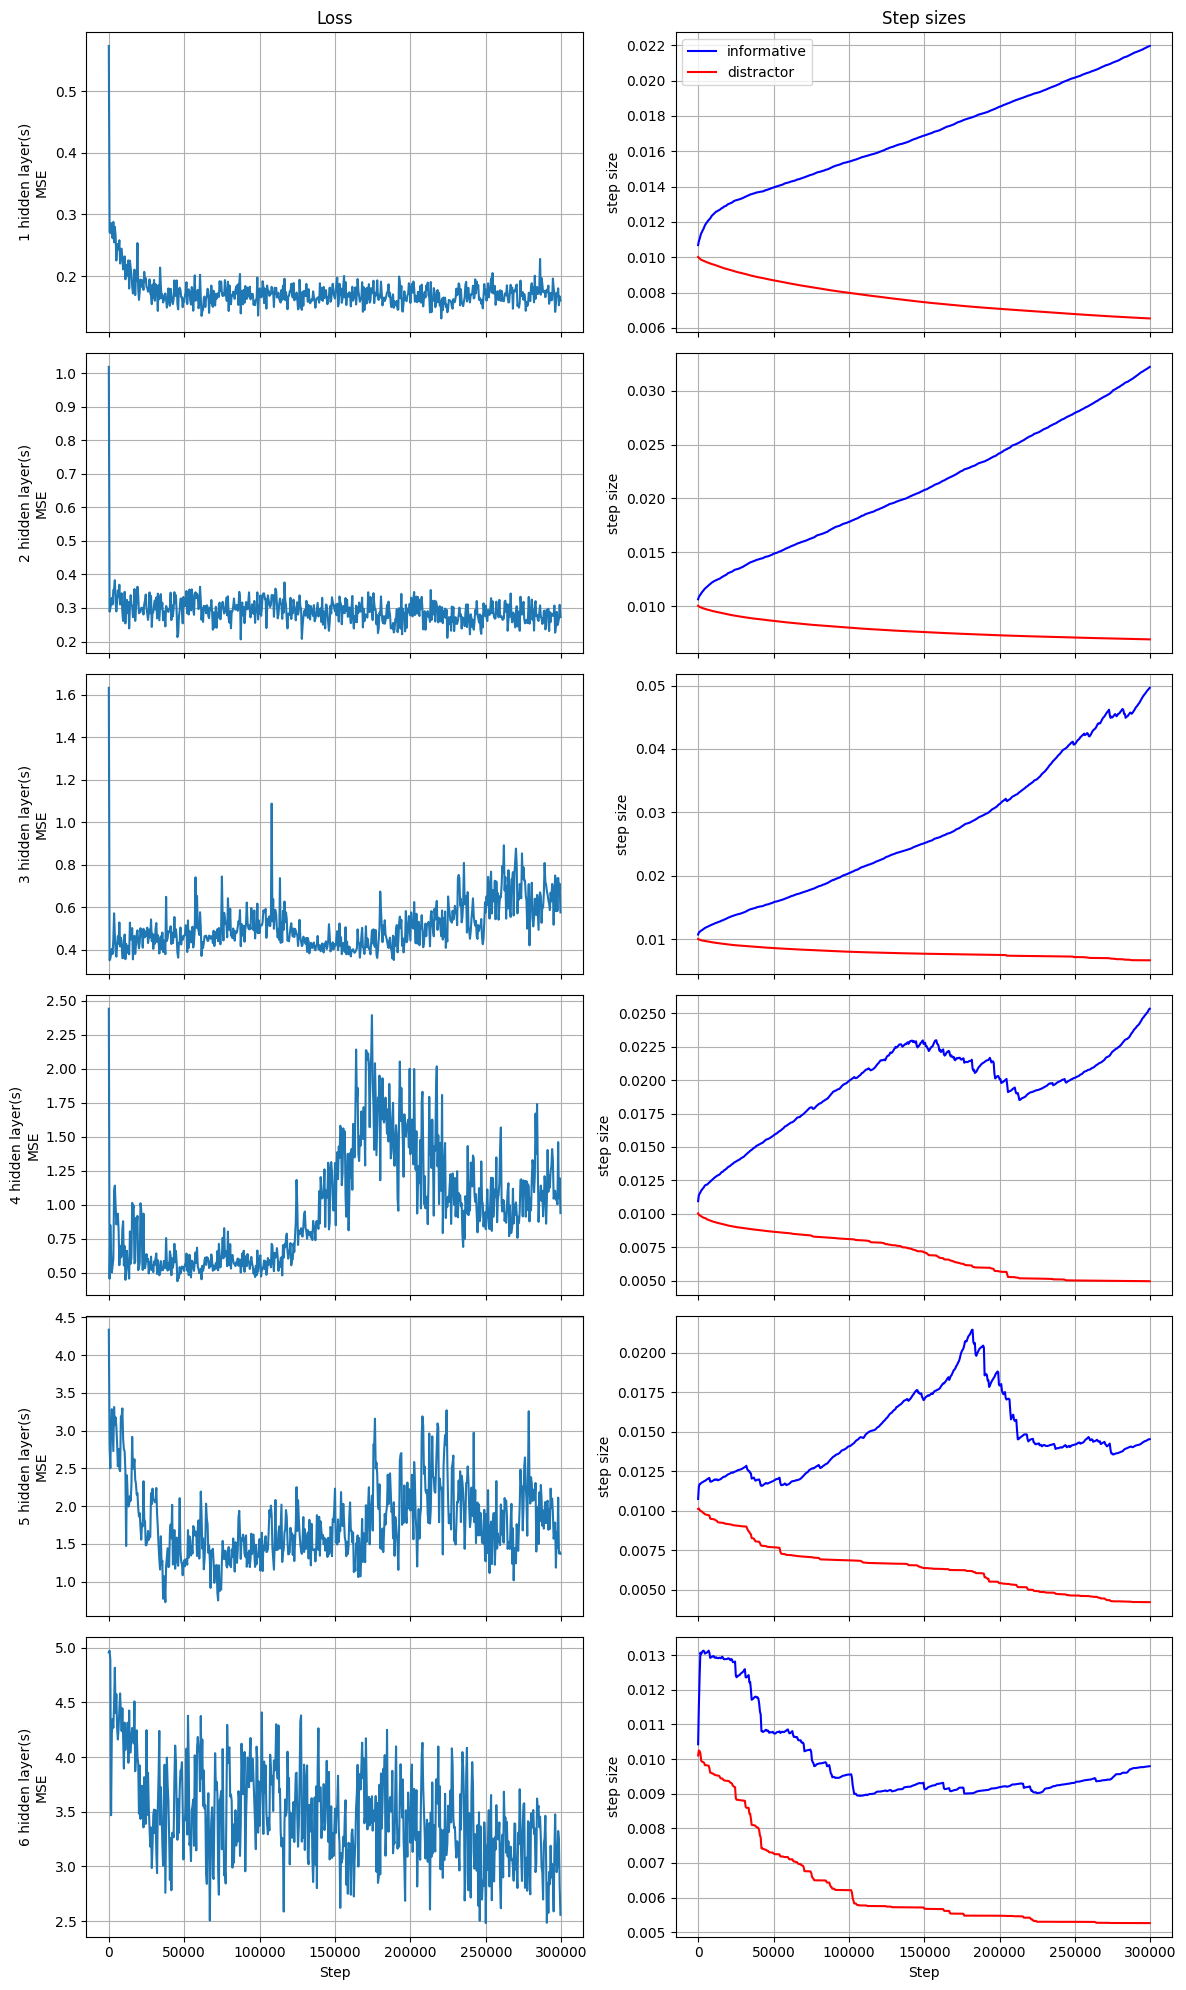

In [51]:
### Depth sweep: 1-6 hidden layers ###
bin_size    = 500
train_steps = 300_000
n_seeds     = 5


# Average over seeds, then smooth into bins.
smooth = lambda a: np.asarray(a).mean(0).reshape(-1, bin_size).mean(1)
steps  = np.arange(train_steps // bin_size) * bin_size

fig, axes = plt.subplots(6, 2, figsize=(12, 20), sharex=True)
for row, n_hidden in enumerate(range(1, 7)):
    network = create_network(n_layers=n_hidden + 1, hidden_dim=20)
    optimizer = make_optimizer(network, step_size=0.01, meta_step_size=0.01)
    learner_state = LearnerState(network, optimizer)
    metrics = run_experiment(learner_state, train_steps, idbd_update, n_seeds)

    ax_loss, ax_ss = axes[row]
    ax_loss.plot(steps, smooth(metrics['loss']))
    ax_loss.set_ylabel(f'{n_hidden} hidden layer(s)\nMSE')
    ax_loss.grid(True)

    ax_ss.plot(steps, smooth(metrics['informative_step_size_mean']), color='blue', label='informative')
    ax_ss.plot(steps, smooth(metrics['distractor_step_size_mean']),  color='red',  label='distractor')
    ax_ss.set_ylabel('step size')
    ax_ss.grid(True)

axes[0, 0].set_title('Loss')
axes[0, 1].set_title('Step sizes')
axes[0, 1].legend()
axes[-1, 0].set_xlabel('Step')
axes[-1, 1].set_xlabel('Step')
plt.tight_layout()
plt.show()


## Width Tests

Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will probably cause a silent bug.
Found multiple sets of weights, but AutoStep does not support non-linear  layer structures. If the weights provided to AutoStep are stacked and not independent, then this will prob

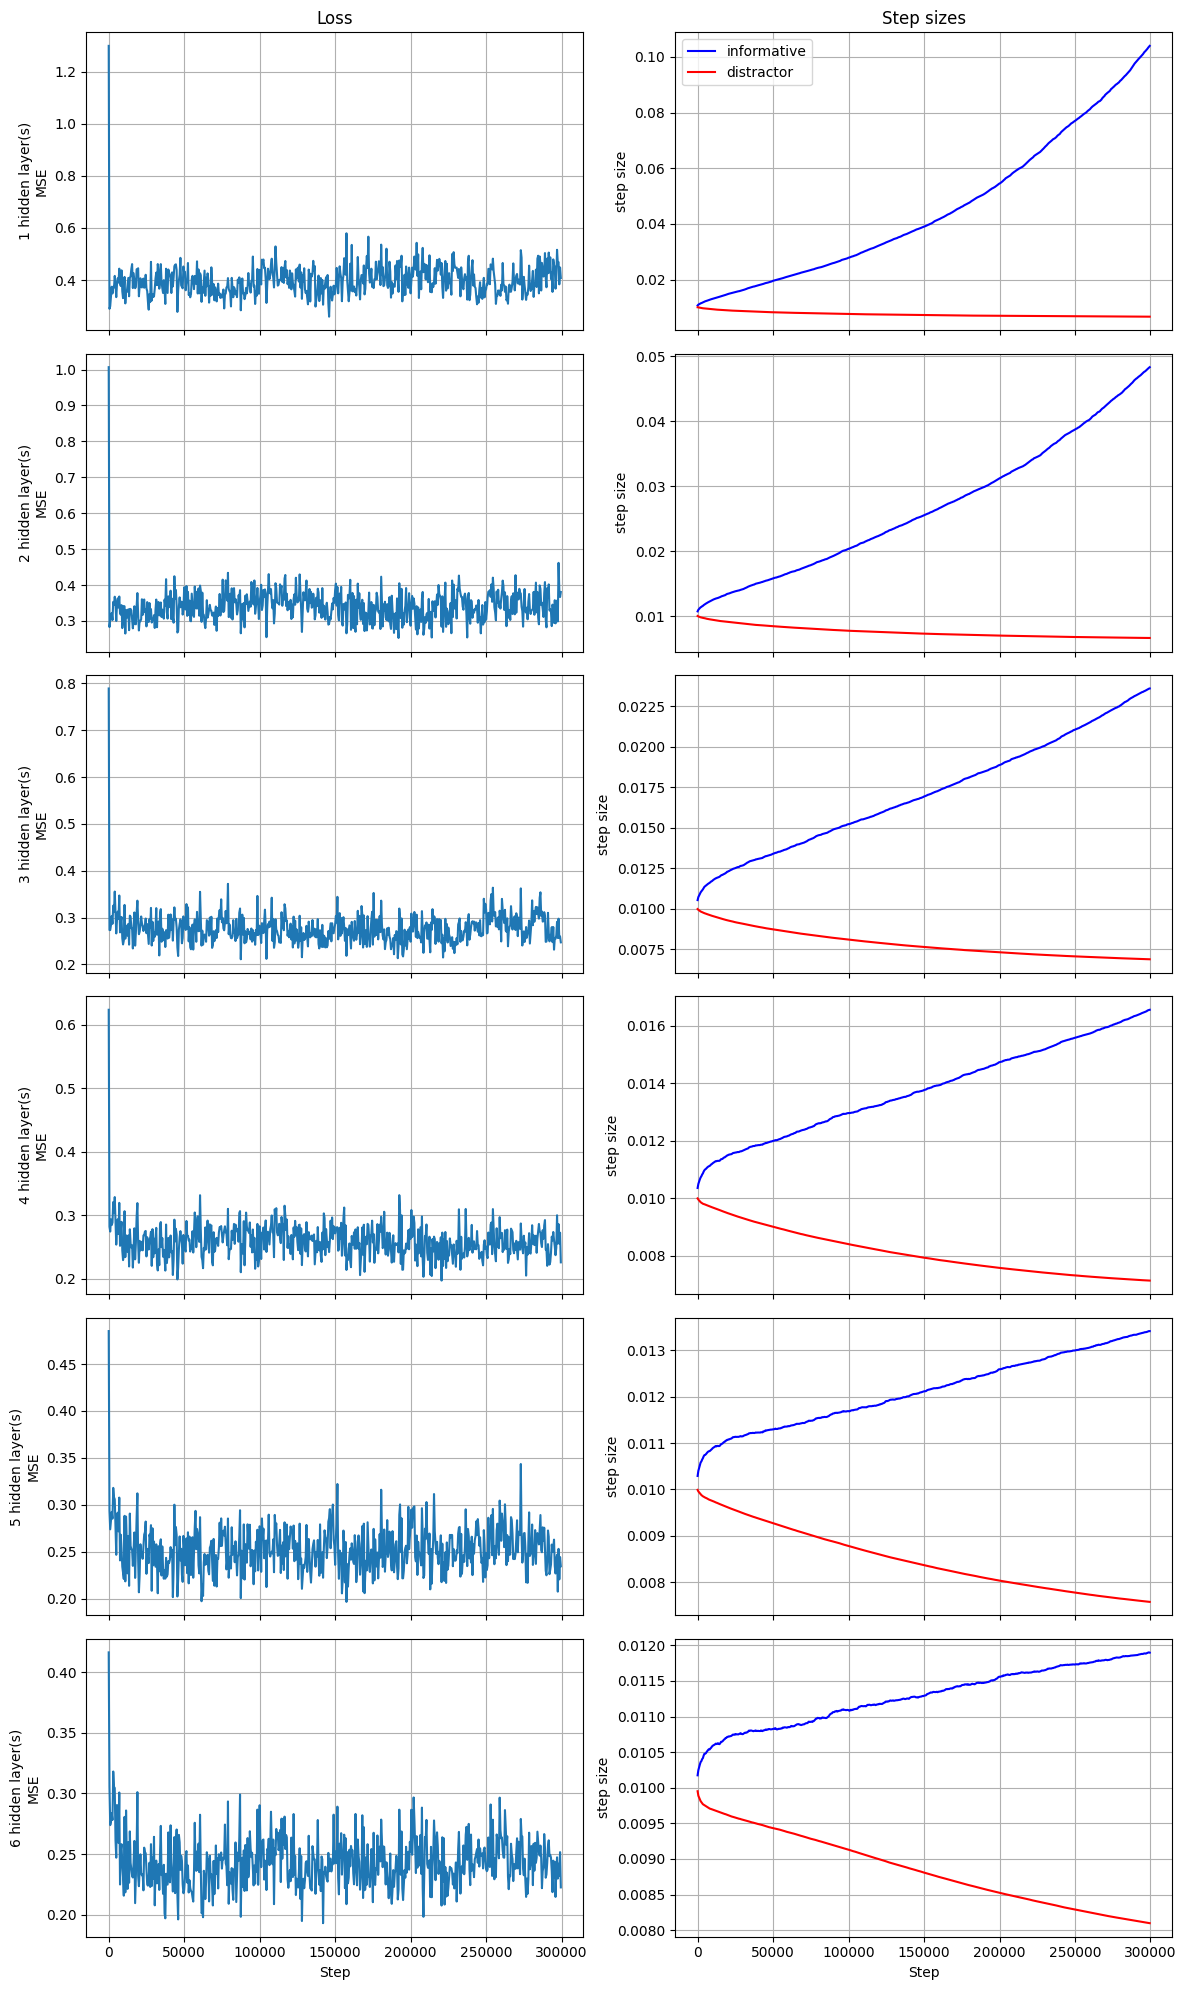

In [7]:
### Width sweep: 8-256 hidden units ###
bin_size    = 500
train_steps = 300_000
n_seeds     = 5


# Average over seeds, then smooth into bins.
smooth = lambda a: np.asarray(a).mean(0).reshape(-1, bin_size).mean(1)
steps  = np.arange(train_steps // bin_size) * bin_size

fig, axes = plt.subplots(6, 2, figsize=(12, 20), sharex=True)
for row, n_hidden in enumerate(range(1, 7)):
    network = create_network(n_layers=3, hidden_dim=2**(row+3))
    optimizer = make_optimizer(network, step_size=0.01, meta_step_size=0.01)
    learner_state = LearnerState(network, optimizer)
    metrics = run_experiment(learner_state, train_steps, idbd_update, n_seeds)

    ax_loss, ax_ss = axes[row]
    ax_loss.plot(steps, smooth(metrics['loss']))
    ax_loss.set_ylabel(f'{n_hidden} hidden layer(s)\nMSE')
    ax_loss.grid(True)

    ax_ss.plot(steps, smooth(metrics['informative_step_size_mean']), color='blue', label='informative')
    ax_ss.plot(steps, smooth(metrics['distractor_step_size_mean']),  color='red',  label='distractor')
    ax_ss.set_ylabel('step size')
    ax_ss.grid(True)

axes[0, 0].set_title('Loss')
axes[0, 1].set_title('Step sizes')
axes[0, 1].legend()
axes[-1, 0].set_xlabel('Step')
axes[-1, 1].set_xlabel('Step')
plt.tight_layout()
plt.show()
